# 🌾 Rice Leaf Disease Classification System

## 📌 Overview

This system is designed to automatically identify rice leaf diseases from images and distinguish whether the input image actually belongs to a rice plant or not. It uses a deep learning model based on transfer learning to ensure both accuracy and efficiency.

---

## 🧠 Model Architecture

The model is built using **MobileNetV2**, a lightweight convolutional neural network suitable for real-time and web-based applications.

### 🔹 Key Components:

* **Base Model:** MobileNetV2 (pre-trained on ImageNet)
* **Input Size:** 160 × 160 pixels
* **Feature Extraction:** Convolutional layers from MobileNetV2
* **Pooling Layer:** GlobalAveragePooling2D
* **Regularization:** Batch Normalization + Dropout
* **Output Layer:** Dense layer with Softmax activation

---

## 📂 Dataset Composition

The training dataset is a combination of two sources:

### ✅ Rice Disease Dataset

Contains labeled images of rice leaves with the following classes:

* Blast
* Healthy
* Insect
* Scald
* Stripes
* Tungro

### ❌ Background Dataset (Non-Rice)

Images from a general plant dataset are used as a **"Background" class**.
This includes leaves from other plants such as tomato, potato, and pepper.

---

## ⚙️ How the Model Works

### Step 1: Image Preprocessing

* Input image is resized to **160 × 160**
* Pixel values are normalized (scaled between 0 and 1)

### Step 2: Feature Extraction

* The image is passed through MobileNetV2
* The network extracts important visual features such as:

  * Leaf texture
  * Color variations
  * Disease patterns (spots, lesions)

### Step 3: Classification

* Extracted features are passed through the final dense layer
* The model outputs probabilities for each class using **Softmax**

---

## 🔍 Disease Prediction

If the image belongs to a rice leaf, the model predicts one of the disease classes:

* Example output:

```json
{
  "label": "blast",
  "confidence": 0.95
}
```

The prediction is based on learned patterns such as:

* Shape and distribution of lesions
* Color changes in the leaf
* Texture irregularities

---

## 🚫 Non-Rice Detection (Background Class)

A key feature of this system is its ability to detect **non-rice images**.

### How it works:

* The model is trained with a separate class called **"background"**
* This class contains images of leaves that are NOT rice

### During inference:

* If the predicted class is `"background"`, the system concludes:

  * The image is **not a rice leaf**

### Example output:

```json
{
  "label": "background",
  "is_rice": false,
  "confidence": 0.98
}
```

---

## 🎯 Final Decision Logic

| Prediction               | Meaning                |
| ------------------------ | ---------------------- |
| Rice class (e.g., Blast) | Rice leaf with disease |
| Healthy                  | Healthy rice leaf      |
| Background               | Not a rice leaf        |

---

## 🚀 Advantages of This Approach

* ✅ Handles real-world inputs (not limited to rice images)
* ✅ Lightweight model suitable for deployment
* ✅ Robust to variations in lighting and background
* ✅ Reduces false predictions on unrelated images

---

## 📌 Conclusion

This system combines **disease classification** and **input validation** in a single model.
By introducing a "background" class, it ensures that predictions are reliable even when non-rice images are provided.

This makes the model suitable for real-world applications such as:

* Mobile apps for farmers
* Web-based disease detection systems
* Smart agriculture solutions

---


In [ ]:
import os
import shutil
import json
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing import image

In [ ]:
RICE_TRAIN = "/kaggle/input/datasets/chaitanyakamble69/rice-leaf-disease-riceguard-19k-cleaned/train"
PLANT_PATH = "/kaggle/input/datasets/emmarex/plantdisease/PlantVillage"

FINAL_PATH = "/kaggle/working/final_dataset/train"

VALID_CLASSES = ["blast", "healthy", "insect", "scald", "stripes", "tungro"]

def prepare_dataset():
    print("🚀 Preparing dataset...")

    os.makedirs(FINAL_PATH, exist_ok=True)

    # ✅ Copy Rice Classes
    for cls in VALID_CLASSES:
        src = os.path.join(RICE_TRAIN, cls)
        dst = os.path.join(FINAL_PATH, cls)

        os.makedirs(dst, exist_ok=True)

        for img in os.listdir(src):
            shutil.copy(os.path.join(src, img), dst)

    print("✅ Rice dataset copied")

    # ✅ Create Background Class
    bg_path = os.path.join(FINAL_PATH, "background")
    os.makedirs(bg_path, exist_ok=True)

    for folder in os.listdir(PLANT_PATH):
        folder_path = os.path.join(PLANT_PATH, folder)

        if os.path.isdir(folder_path):
            for img in os.listdir(folder_path)[:150]:  # limit per class
                shutil.copy(os.path.join(folder_path, img), bg_path)

    print("✅ Background class created")

prepare_dataset()

🚀 Preparing dataset...
✅ Rice dataset copied
✅ Background class created


In [ ]:
IMG_SIZE = (160, 160)
BATCH_SIZE = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

train_gen = datagen.flow_from_directory(
    FINAL_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_gen = datagen.flow_from_directory(
    FINAL_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

print("Classes:", train_gen.class_indices)

Found 11124 images belonging to 7 classes.
Found 2777 images belonging to 7 classes.
Classes: {'background': 0, 'blast': 1, 'healthy': 2, 'insect': 3, 'scald': 4, 'stripes': 5, 'tungro': 6}


In [ ]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(160, 160, 3)
)

# 🔥 Fine-tune last layers
for layer in base_model.layers[:-30]:
    layer.trainable = False

for layer in base_model.layers[-30:]:
    layer.trainable = True

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dropout(0.3)(x)   # 🔥 important
output = Dense(train_gen.num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 160, 160,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 80, 80,    │        864 │ input_layer_3[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 80, 80,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 80, 80,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 80, 80,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 80, 80,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 80, 80,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 80, 80,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 80, 80,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 80, 80,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 80, 80,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 80, 80,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 81, 81,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 40, 40,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 40, 40,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 40, 40,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 40, 40,    │      2,304 │ block_1_depthwis

 Total params: 2,272,071 (8.67 MB)

 Trainable params: 1,537,927 (5.87 MB)

 Non-trainable params: 734,144 (2.80 MB)

In [ ]:
EPOCHS = 25

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS
)

Epoch 1/25
348/348 ━━━━━━━━━━━━━━━━━━━━ 266s 716ms/step - accuracy: 0.5117 - loss: 1.4703 - val_accuracy: 0.4177 - val_loss: 2.7904
Epoch 2/25
348/348 ━━━━━━━━━━━━━━━━━━━━ 239s 688ms/step - accuracy: 0.6844 - loss: 0.8668 - val_accuracy: 0.4761 - val_loss: 2.0919
Epoch 3/25
348/348 ━━━━━━━━━━━━━━━━━━━━ 239s 686ms/step - accuracy: 0.7187 - loss: 0.7731 - val_accuracy: 0.6035 - val_loss: 1.2741
Epoch 4/25
348/348 ━━━━━━━━━━━━━━━━━━━━ 242s 697ms/step - accuracy: 0.7346 - loss: 0.7064 - val_accuracy: 0.6914 - val_loss: 0.9123
Epoch 5/25
348/348 ━━━━━━━━━━━━━━━━━━━━ 238s 684ms/step - accuracy: 0.7632 - loss: 0.6382 - val_accuracy: 0.7047 - val_loss: 0.8087
Epoch 6/25
348/348 ━━━━━━━━━━━━━━━━━━━━ 246s 707ms/step - accuracy: 0.7616 - loss: 0.6192 - val_accuracy: 0.7541 - val_loss: 0.6824
Epoch 7/25
348/348 ━━━━━━━━━━━━━━━━━━━━ 271s 778ms/step - accuracy: 0.7804 - loss: 0.5747 - val_accuracy: 0.7663 - val_loss: 0.6679
Epoch 8/25
348/348 ━━━━━━━━━━━━━━━━━━━━ 264s 758ms/step - accuracy: 0.7938 -

In [ ]:
model.save("/kaggle/working/rice_model_final.h5")

with open("/kaggle/working/class_indices.json", "w") as f:
    json.dump(train_gen.class_indices, f)

print("✅ Model and class mapping saved")

✅ Model and class mapping saved


In [ ]:
import numpy as np
import json
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image

MODEL_PATH = "/kaggle/working/rice_model_final.h5"
CLASS_PATH = "/kaggle/working/class_indices.json"
IMG_SIZE = (160, 160)

# Load once (important for speed)
model = load_model(MODEL_PATH)

with open(CLASS_PATH) as f:
    class_indices = json.load(f)

idx_to_class = {v: k for k, v in class_indices.items()}

def predict_image(img_path):
    img = image.load_img(img_path, target_size=IMG_SIZE)
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    pred = model.predict(img_array, verbose=0)
    idx = np.argmax(pred)
    confidence = float(np.max(pred))

    label = idx_to_class[idx]

    return label, confidence

In [ ]:
import os

TEST_PATH = "/kaggle/input/datasets/chaitanyakamble69/rice-leaf-disease-riceguard-19k-cleaned/test"

results = []

for class_name in os.listdir(TEST_PATH):
    class_path = os.path.join(TEST_PATH, class_name)

    for img_name in os.listdir(class_path)[:5]:  # limit for quick test
        img_path = os.path.join(class_path, img_name)

        pred_label, conf = predict_image(img_path)

        results.append({
            "actual": class_name,
            "predicted": pred_label,
            "confidence": conf,
            "path": img_path
        })

2026-04-26 11:15:27.124268: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-26 11:15:27.272114: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-26 11:15:27.405709: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


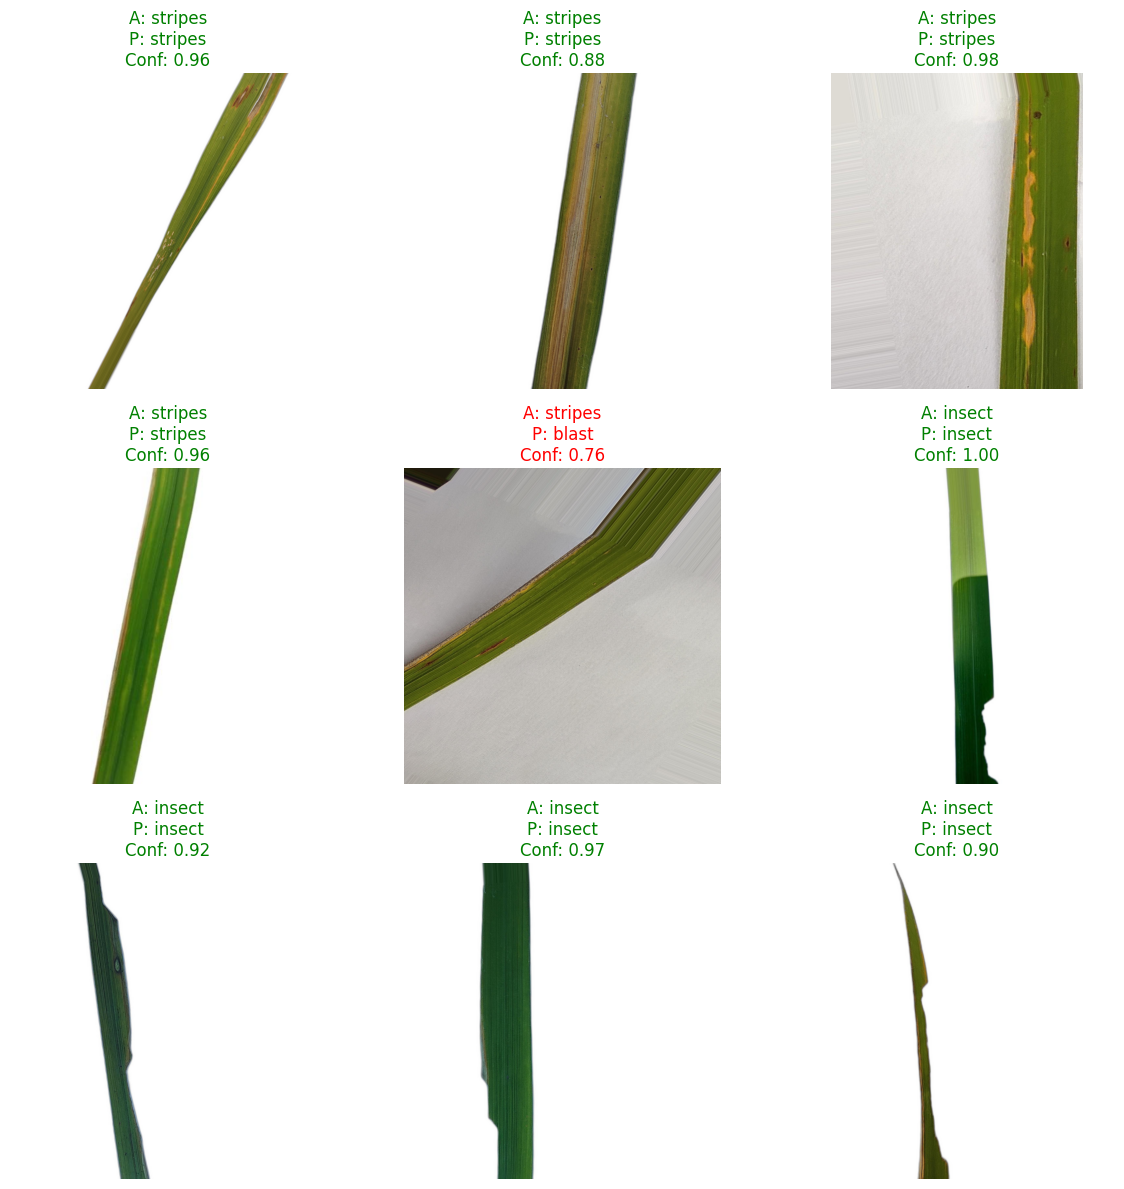

In [ ]:
import matplotlib.pyplot as plt

def visualize_results(results, num_images=9):
    plt.figure(figsize=(12, 12))

    for i, res in enumerate(results[:num_images]):
        img = image.load_img(res["path"])

        plt.subplot(3, 3, i+1)
        plt.imshow(img)
        plt.axis("off")

        correct = res["actual"] == res["predicted"]

        title_color = "green" if correct else "red"

        plt.title(
            f"A: {res['actual']}\nP: {res['predicted']}\nConf: {res['confidence']:.2f}",
            color=title_color
        )

    plt.tight_layout()
    plt.show()

# Run visualization
visualize_results(results)

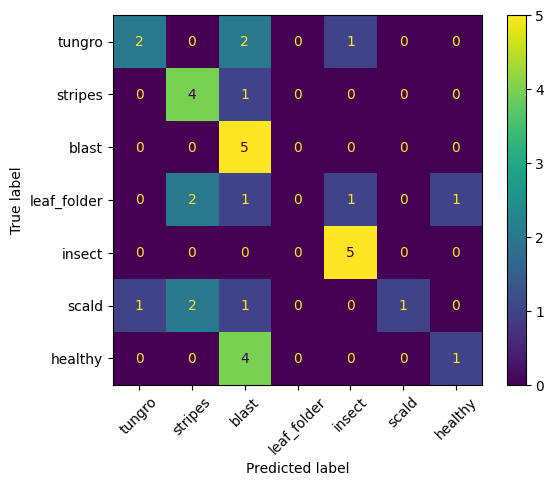

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

y_true = [r["actual"] for r in results]
y_pred = [r["predicted"] for r in results]

labels = list(set(y_true))

cm = confusion_matrix(y_true, y_pred, labels=labels)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(xticks_rotation=45)
plt.show()

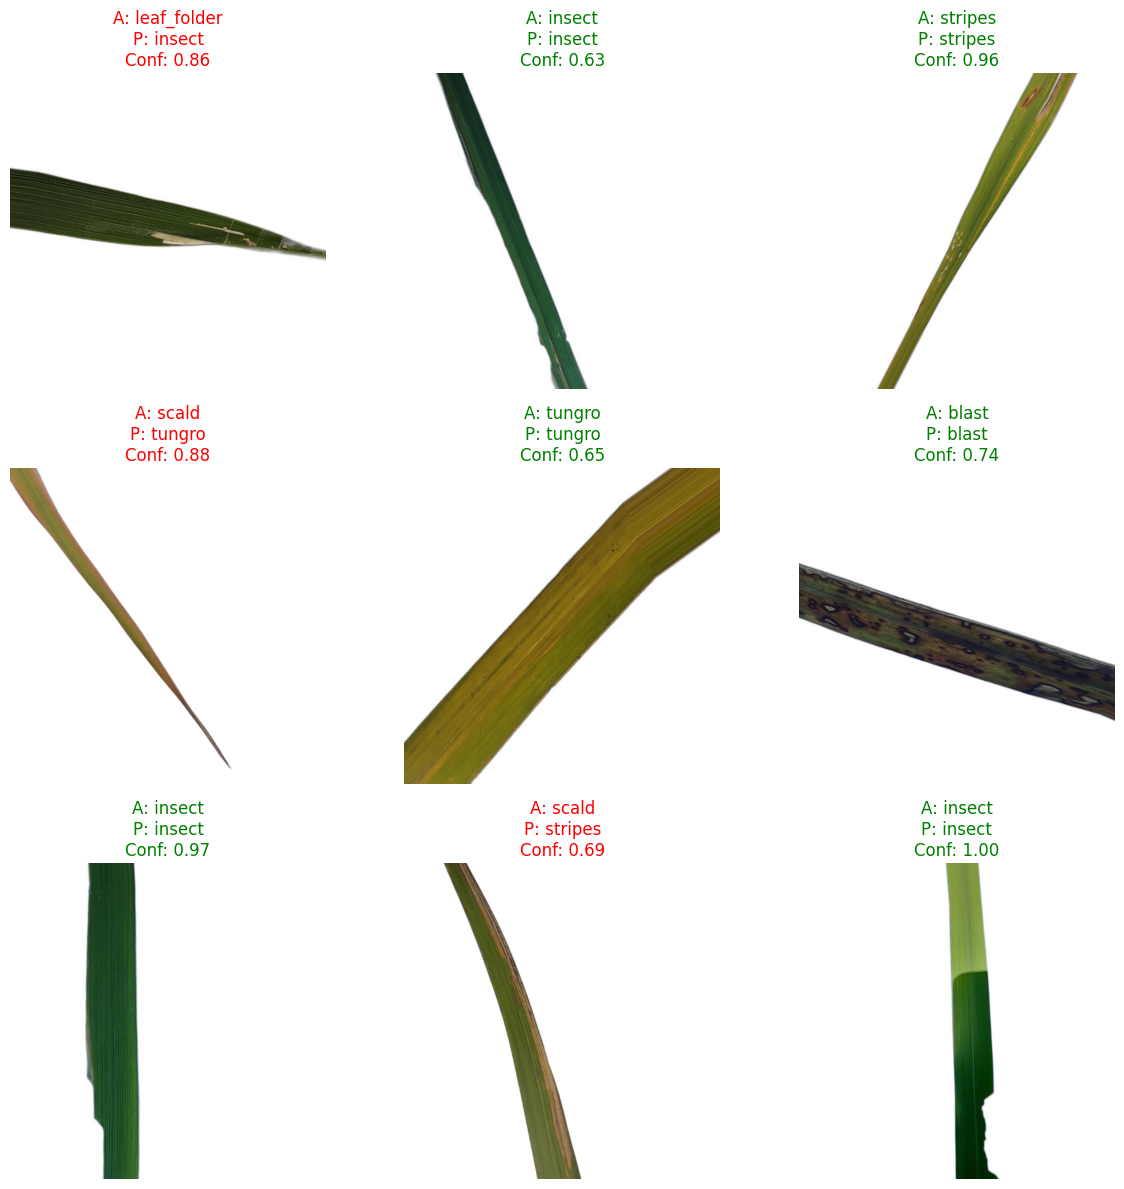

In [ ]:
import matplotlib.pyplot as plt
import random
from tensorflow.keras.preprocessing import image

def visualize_random_results(results, num_images=9):
    # 🔥 Randomly sample results
    sample = random.sample(results, min(num_images, len(results)))

    plt.figure(figsize=(12, 12))

    for i, res in enumerate(sample):
        img = image.load_img(res["path"])

        plt.subplot(3, 3, i+1)
        plt.imshow(img)
        plt.axis("off")

        correct = res["actual"] == res["predicted"]
        title_color = "green" if correct else "red"

        plt.title(
            f"A: {res['actual']}\nP: {res['predicted']}\nConf: {res['confidence']:.2f}",
            color=title_color
        )

    plt.tight_layout()
    plt.show()
visualize_random_results(results)